In [9]:
# 1.all our imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [10]:
#2. load
df = pd.read_csv("georgia_accidents.csv")

In [ ]:
# 3) initial look at the data
display(df.head(5))

Shape: (169234, 47)


,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,146255,A-146262,Source2,3,2016-11-30 15:13:44,2016-11-30 17:26:28,33.546177,-84.577347,NaN,NaN,...,False,False,False,False,False,False,Day,Day,Day,Day
1,146256,A-146263,Source2,3,2016-11-30 15:25:27,2016-11-30 16:54:36,33.766376,-84.527321,NaN,NaN,...,False,False,False,False,False,False,Day,Day,Day,Day
2,146257,A-146264,Source2,3,2016-11-30 14:42:27,2016-11-30 16:57:07,33.786896,-84.493134,NaN,NaN,...,False,False,False,False,False,False,Day,Day,Day,Day
3,146258,A-146265,Source2,2,2016-11-30 16:27:58,2016-11-30 16:57:41,33.697849,-84.418266,NaN,NaN,...,False,False,False,False,False,False,Day,Day,Day,Day
4,146259,A-146266,Source2,3,2016-11-30 16:14:20,2016-11-30 16:58:59,33.696915,-84.404984,NaN,NaN,...,False,False,False,False,False,False,Day,Day,Day,Day


Shape of dataset: (169234, 49)

Column names:
['Unnamed: 0', 'ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Hour', 'DayOfWeek']


,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,...,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,DayOfWeek
0,146255,A-146262,Source2,3,2016-11-30 15:13:44,2016-11-30 17:26:28,33.546177,-84.577347,NaN,NaN,...,False,False,False,False,Day,Day,Day,Day,15.0,2.0
1,146256,A-146263,Source2,3,2016-11-30 15:25:27,2016-11-30 16:54:36,33.766376,-84.527321,NaN,NaN,...,False,False,False,False,Day,Day,Day,Day,15.0,2.0
2,146257,A-146264,Source2,3,2016-11-30 14:42:27,2016-11-30 16:57:07,33.786896,-84.493134,NaN,NaN,...,False,False,False,False,Day,Day,Day,Day,14.0,2.0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169234 entries, 0 to 169233
Data columns (total 49 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             169234 non-null  int64         
 1   ID                     169234 non-null  object        
 2   Source                 169234 non-null  object        
 3   Severity               169234 non-null  int64         
 4   Start_Time             156322 non-null  datetime64[ns]
 5   End_Time               169234 non-null  object        
 6   Start_Lat              169234 non-null  float64       
 7   Start_Lng              169234 non-null  float64       
 8   End_Lat                75056 non-null   float64       
 9   End_Lng                75056 non-null   float64       
 10  Distance(mi)           169234 non-null  float64       
 11  Description            169234 non-null  object        
 12  Street                 168819 no

End_Lat              55.649574
End_Lng              55.649574
Precipitation(in)    37.816278
Wind_Chill(F)        36.056584
Wind_Speed(mph)       9.532954
DayOfWeek             7.629673
Start_Time            7.629673
Hour                  7.629673
Humidity(%)           1.969462
Temperature(F)        1.866055
Wind_Direction        1.797511
Visibility(mi)        1.753194
Weather_Condition     1.598379
Pressure(in)          1.516835
Weather_Timestamp     1.356701
dtype: float64


Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,169234.0,3.327715e+06,2.278541e+06,146255.000000,1.389668e+06,3.017831e+06,4.989331e+06,7.728073e+06
Severity,169234.0,2.506931e+00,6.425273e-01,1.000000,2.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00
Start_Lat,169234.0,3.358936e+01,5.989669e-01,30.606814,3.351137e+01,3.374818e+01,3.388148e+01,3.499240e+01
Start_Lng,169234.0,-8.398759e+01,8.997973e-01,-85.592430,-8.443706e+01,-8.434901e+01,-8.404093e+01,-8.084386e+01
End_Lat,75056.0,3.353353e+01,7.042999e-01,30.593880,3.350447e+01,3.374504e+01,3.389339e+01,3.502126e+01
End_Lng,75056.0,-8.410161e+01,7.879503e-01,-85.816145,-8.446972e+01,-8.434951e+01,-8.408142e+01,-7.984451e+01
Distance(mi),169234.0,6.270589e-01,1.815421e+00,0.000000,0.000000e+00,1.000000e-02,6.340000e-01,1.324990e+02
Temperature(F),166076.0,6.429436e+01,1.560669e+01,8.000000,5.300000e+01,6.600000e+01,7.600000e+01,1.400000e+02
Wind_Chill(F),108214.0,6.130297e+01,1.769505e+01,-10.000000,5.000000e+01,6.400000e+01,7.500000e+01,1.400000e+02
Humidity(%),165901.0,6.920325e+01,2.201689e+01,4.000000,5.100000e+01,7.200000e+01,9.000000e+01,1.000000e+02


Severity Distribution


C:\Users\sokra\AppData\Local\Temp\ipykernel_5944\2743175243.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_counts.index, y=severity_percent, palette="Blues_d")


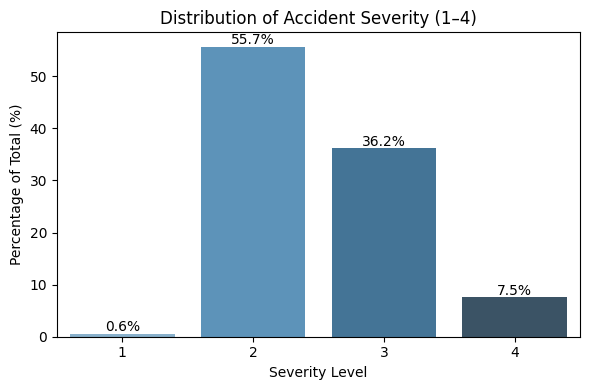

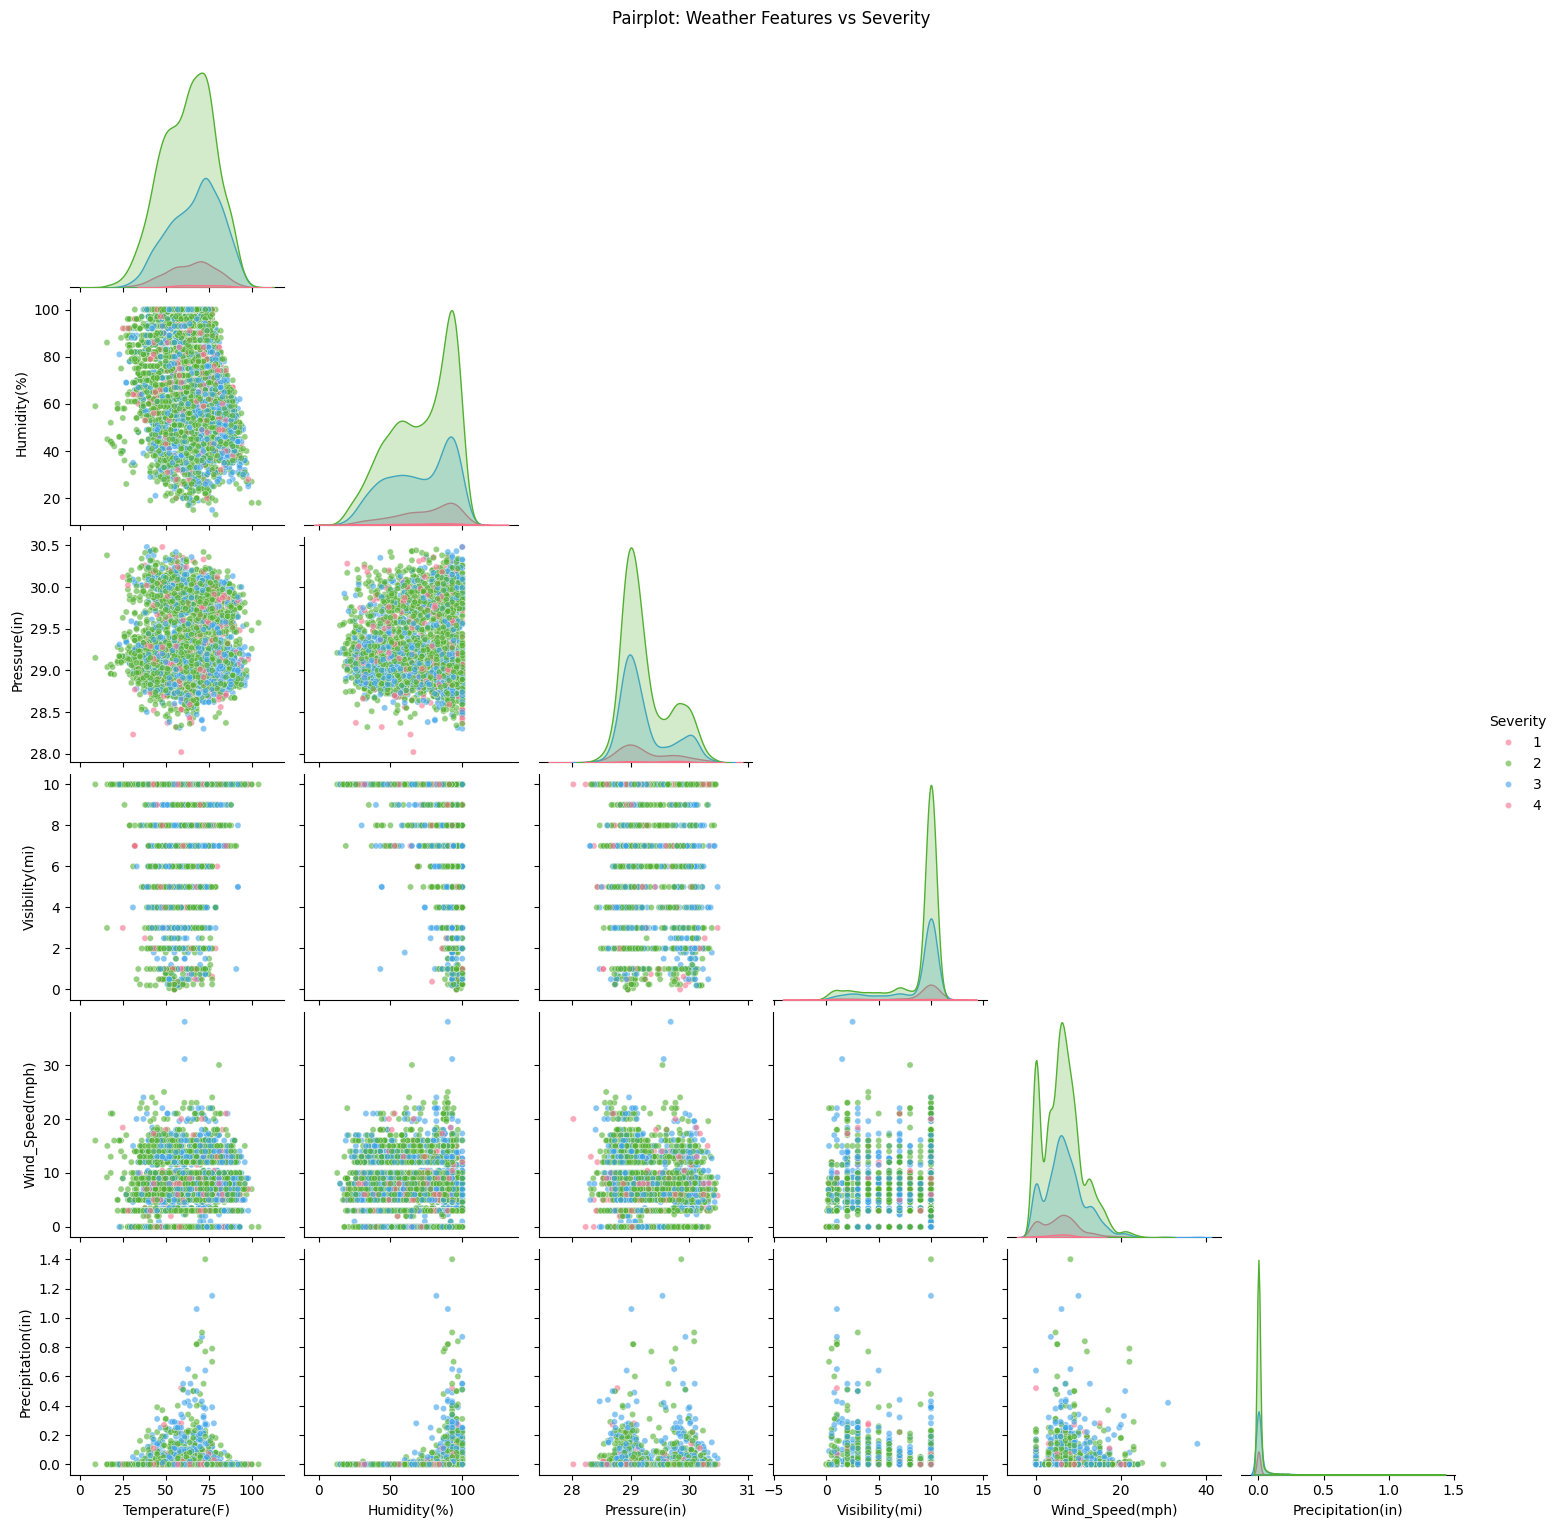

accidents correlation heatmap


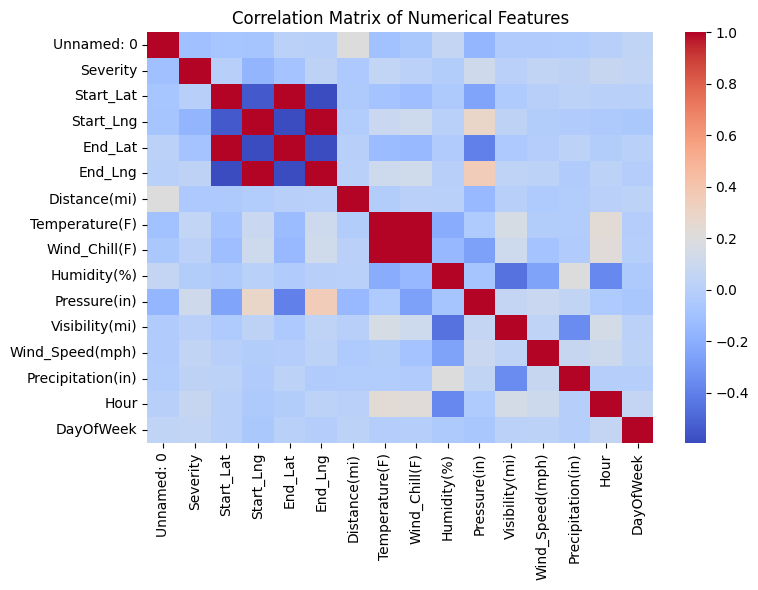

Accidents by hours of the day


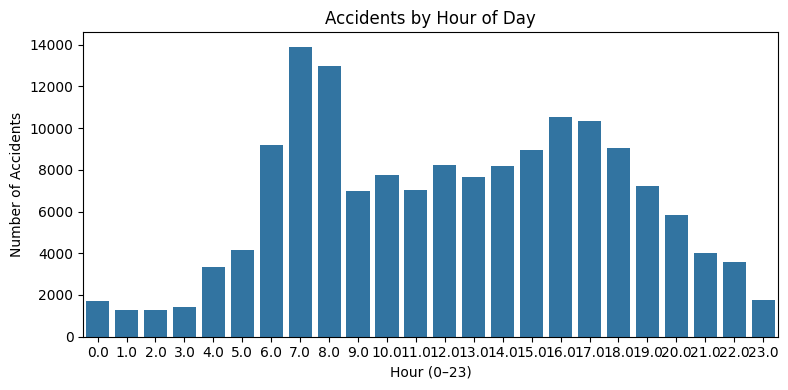

In [ ]:
#Some data exploration
#printing the shape and columns
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
display(df.head(3))

#data info
print("\nData Info:")
df.info()


#missing values
missing = df.isna().mean().sort_values(ascending=False) * 100
print("\nMissing values (%):")
display(missing.head(15))



#Some summary for the data in case we need
print("\nSummary Statistics:")
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
display(df[num_cols].describe().T)


#Severity distribution
print("Severity Distribution")
severity_counts = df["Severity"].value_counts().sort_index()
severity_percent = (severity_counts / len(df)) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=severity_counts.index, y=severity_percent)
plt.title("Distribution of Accident Severity (1–4)")
plt.xlabel("Severity Level")
plt.ylabel("Percentage of Total (%)")
for i, p in enumerate(severity_percent):
    plt.text(i, p + 0.5, f"{p:.1f}%", ha="center")
plt.tight_layout()
plt.show()

#some relevent features that we think are good
plot_cols = [
    "Temperature(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Severity"
]

#drop the null/na values so that it doesn't plot
sample_df = df[plot_cols].dropna().sample(n=5000)

#pairplots for weather features vs severity
sns.pairplot(sample_df, diag_kind="kde", hue="Severity",
             corner=True, plot_kws={'alpha':0.6, 's':20})
plt.suptitle("Pairplot: Weather Features vs Severity",)
plt.show()


#correlation heatmap
print("accidents correlation heatmap")
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


#Accidents by hours of the day
#featured engineered start_time, hour and DayOfWeek so we can plot
print("Accidents by hours of the day")
df["Start_Time"] = pd.to_datetime(df["Start_Time"]) #converting to datetime so pandas can understand
df["Hour"] = df["Start_Time"].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek

plt.figure(figsize=(8,4))
sns.countplot(x="Hour", data=df)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


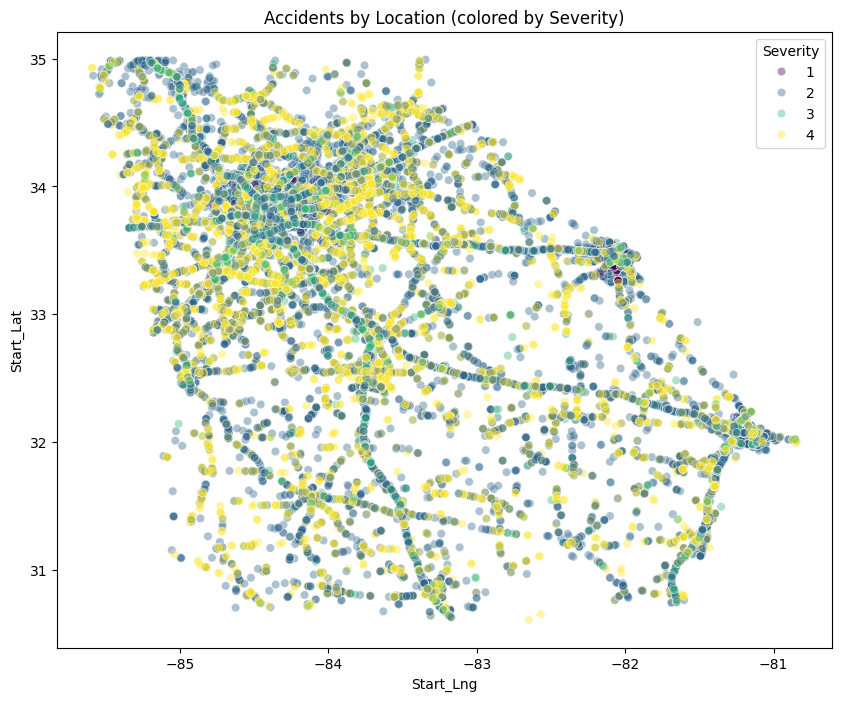

In [13]:
#pair plot using the latitude and longitude. shows the  map of GA
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df,
    x="Start_Lng", y="Start_Lat",
    hue="Severity", alpha=0.4, palette="viridis"
)
plt.title("Accidents by Location (colored by Severity)")
plt.show()


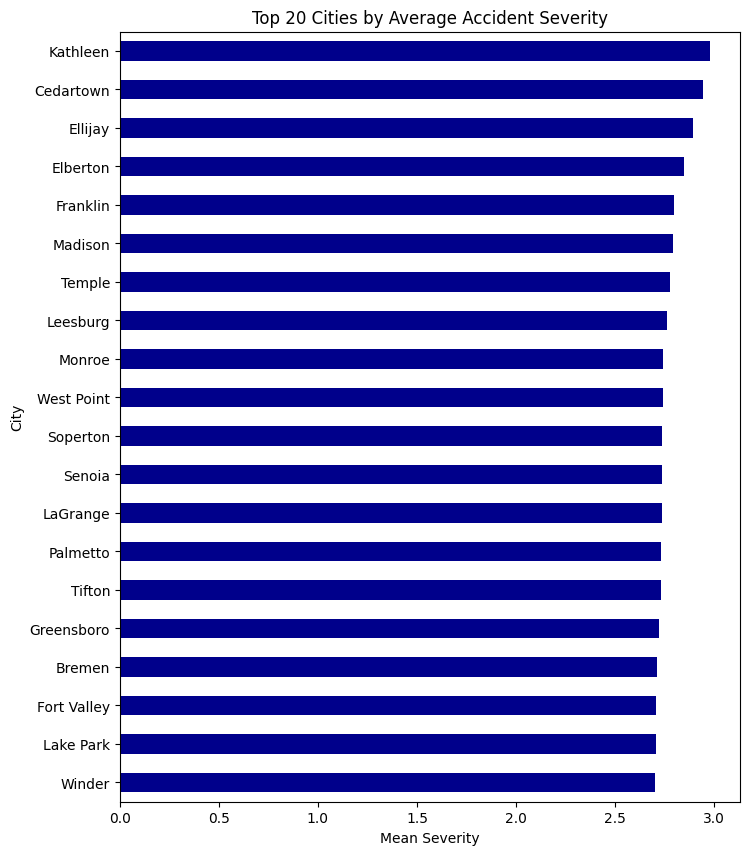

In [14]:
#top 20 cities by average severities, minimum 100 crashes
city_counts = df["City"].value_counts()
valid_cities = city_counts[city_counts >= 100].index

city_severity = (
    df[df["City"].isin(valid_cities)]
    .groupby("City")["Severity"]
    .mean())

city_severity = city_severity.sort_values(ascending=True).tail(20)

city_severity.plot(kind="barh", figsize=(8,10), color="darkblue")
plt.title("Top 20 Cities by Average Accident Severity")
plt.xlabel("Mean Severity")
plt.show()

In [15]:
# 5.Target & features
#setting our target and what we're using as features in the models
target = 'Severity'
numeric_features = [
    "Temperature(F)","Humidity(%)","Pressure(in)","Visibility(mi)",
    "Wind_Speed(mph)","Precipitation(in)","Distance(mi)",
    "Hour","DayOfWeek"
]
categorical_features = [
    "Traffic_Signal","Junction","Crossing","Station",
    "Sunrise_Sunset","Weather_Condition"
]
features = numeric_features + categorical_features

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 6.Processing pipeline for our features
#essentially making it simpler to reuse for our models, like a function, a sequence of processes that we can just call once
#transformer that process the numeric categorical features, filling in with median of that column
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#transformer that process the categorical features, filling in with most frequent value of that column
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore" ))
]
)

#combine both transformers to our dataframes
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features ),
    ("cat", categorical_transformer, categorical_features)
])

Severity Distribution (Counts and Percentages):


,Count,Percentage
Severity,,
1,1007,0.60
2,94206,55.67
3,61245,36.19
4,12776,7.55


C:\Users\sokra\AppData\Local\Temp\ipykernel_5944\1357461331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Severity", data=df, palette="viridis")


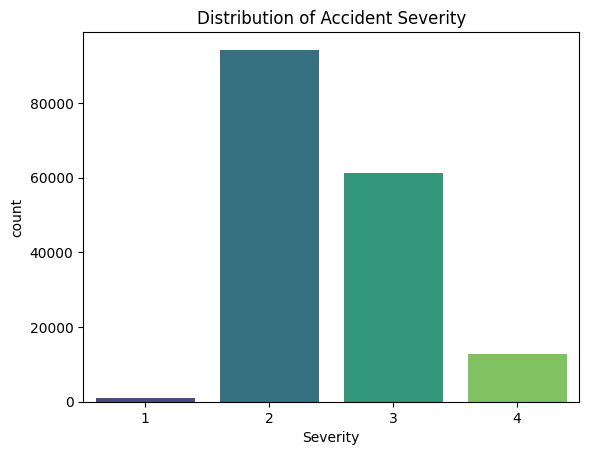

In [17]:
#shows the amount of crashes based on severity
severity_counts = df["Severity"].value_counts().sort_index()
severity_percent = (severity_counts / len(df)) * 100

#combine into a single dataframe
severity_dist = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percent.round(2)
})


#Bar chart for severity distribution
print("Severity Distribution (Counts and Percentages):")
display(severity_dist)
sns.countplot(x="Severity", data=df, palette="viridis")
plt.title("Distribution of Accident Severity")
plt.show()



C:\Users\sokra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report — Logistic Regression
              precision    recall  f1-score   support

  Severity 1       0.02      0.77      0.04       202
  Severity 2       0.79      0.30      0.43     18841
  Severity 3       0.58      0.60      0.59     12249
  Severity 4       0.14      0.40      0.21      2555

    accuracy                           0.42     33847
   macro avg       0.38      0.52      0.32     33847
weighted avg       0.66      0.42      0.47     33847



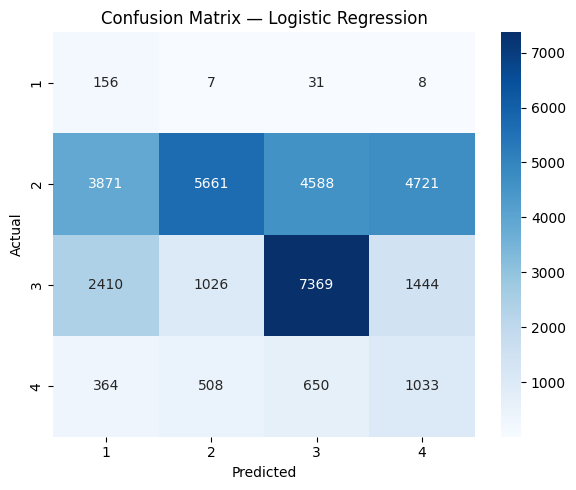

In [18]:
#Logistic Regression
logit_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced"))
])
logit_pipe.fit(X_train, y_train)
y_pred_logit = logit_pipe.predict(X_test)

#making it show 1-4 instead of 0-3 because that's the default for logistic regression
labels = [1, 2, 3, 4]
target_names = ["Severity 1", "Severity 2", "Severity 3", "Severity 4"]

print("Classification Report — Logistic Regression")
print(classification_report(y_test, y_pred_logit, labels=labels, target_names=target_names))

cm = confusion_matrix(y_test, y_pred_logit, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Classification Report — Random Forest
              precision    recall  f1-score   support

  Severity 1       0.02      0.77      0.04       202
  Severity 2       0.79      0.30      0.43     18841
  Severity 3       0.58      0.60      0.59     12249
  Severity 4       0.14      0.40      0.21      2555

    accuracy                           0.42     33847
   macro avg       0.38      0.52      0.32     33847
weighted avg       0.66      0.42      0.47     33847



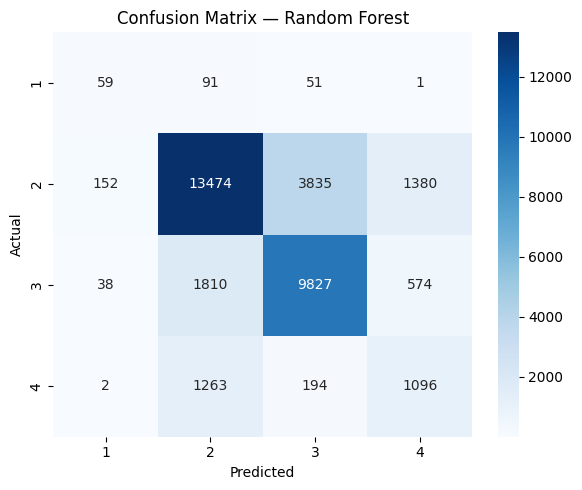

In [ ]:
# 8.Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight="balanced_subsample"))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
labels = [1, 2, 3, 4]
target_names = ["Severity 1", "Severity 2", "Severity 3", "Severity 4"]

print("Classification Report — Random Forest")
print(classification_report(y_test, y_pred_logit, labels=labels, target_names=target_names))

cm = confusion_matrix(y_test, y_pred_rf,labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

Classification Report — KNN
              precision    recall  f1-score   support

  Severity 1       0.02      0.77      0.04       202
  Severity 2       0.79      0.30      0.43     18841
  Severity 3       0.58      0.60      0.59     12249
  Severity 4       0.14      0.40      0.21      2555

    accuracy                           0.42     33847
   macro avg       0.38      0.52      0.32     33847
weighted avg       0.66      0.42      0.47     33847



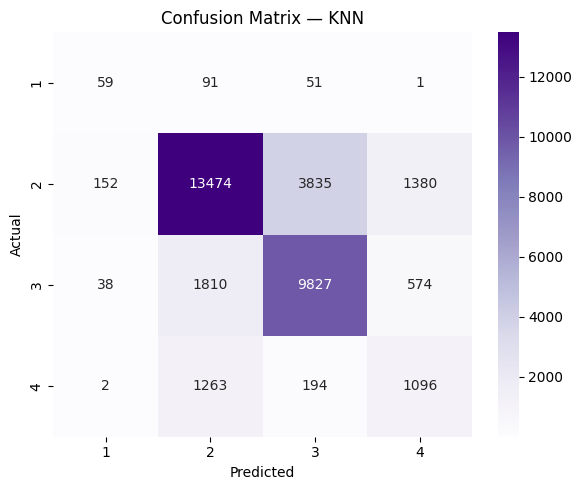

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

#10. K-Nearest Neighbors
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor  ),
    ("clf", KNeighborsClassifier(
    n_neighbors=7,
        weights='distance',
        n_jobs=-1
    ))
])

#Train
knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)

labels = [1, 2, 3, 4]
target_names = ["Severity 1","Severity 2", "Severity 3", "Severity 4"]

print("Classification Report — KNN")
print(classification_report(y_test, y_pred_logit, labels=labels, target_names=target_names,))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


Model Comparison Summary:


,Model,Accuracy,Macro-F1,Weighted-F1
0,Logistic Regression,0.420096,0.320788,0.472556
1,Random Forest,0.722546,0.540614,0.725806
2,KNN,0.685881,0.482344,0.677553


<Figure size 700x400 with 0 Axes>

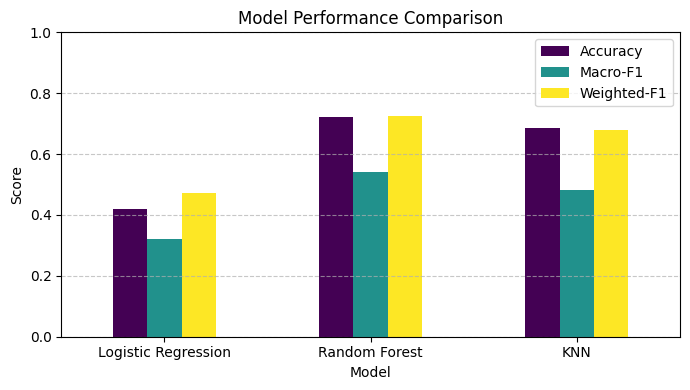

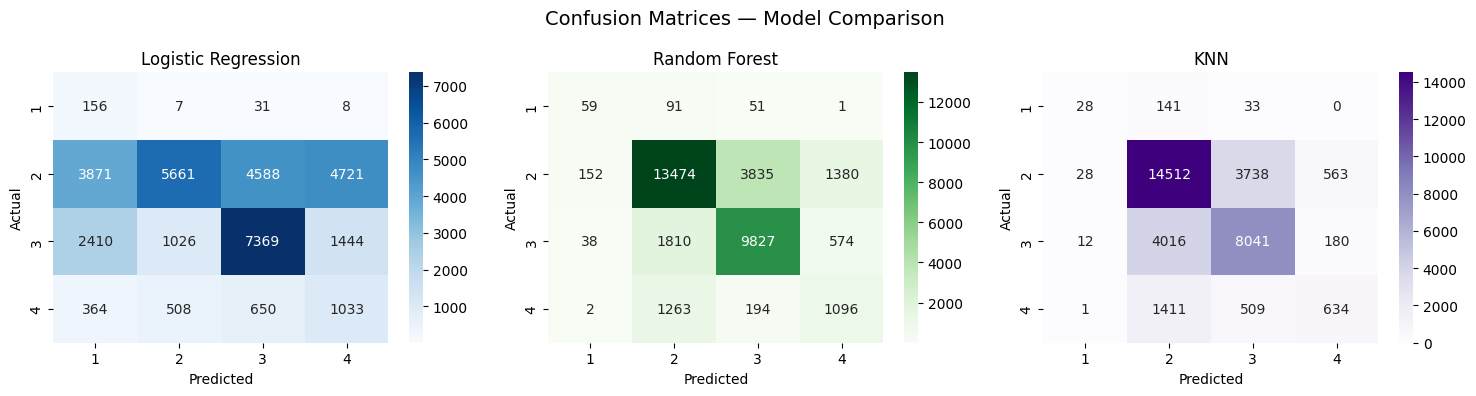

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

#Utility function for metric summary
def model_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted")
    }

#collect metrics from all models
comparison = pd.DataFrame([
    model_metrics(y_test, y_pred_logit, "Logistic Regression"),
    model_metrics(y_test, y_pred_rf, "Random Forest"),
    model_metrics(y_test, y_pred_knn, "KNN")
])
print("Model Comparison Summary:")
display(comparison)


plt.figure(figsize=(7,4))
comparison.set_index("Model")[["Accuracy", "Macro-F1", "Weighted-F1"]].plot(
    kind="bar", figsize=(7,4), colormap="viridis", rot=0
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#confusion table comparisons

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", y_pred_logit, "Blues"),
    ("Random Forest", y_pred_rf, "Greens"),
    ("KNN", y_pred_knn, "Purples")
]

for ax, (title, preds, cmap) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()
